In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor


In [102]:
file_path = r"C:\Solar_SUDHA_maam\fixed_solar.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.lower()

df["time"] = pd.to_datetime(df["time"], dayfirst=True)

df = df.sort_values("time").reset_index(drop=True)

df.head()


,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation
0,2022-01-08 05:00:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
1,2022-01-08 05:05:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
2,2022-01-08 05:10:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
3,2022-01-08 05:15:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
4,2022-01-08 05:20:00,0,0.0,0.0,28.1,63.0,15.766,0.0039


In [103]:
df["hour"] = df["time"].dt.hour + df["time"].dt.minute/60
df["dayofyear"] = df["time"].dt.dayofyear

# Cyclical encoding
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["doy_sin"] = np.sin(2*np.pi*df["dayofyear"]/365)
df["doy_cos"] = np.cos(2*np.pi*df["dayofyear"]/365)


In [104]:
features = [
    "temp",
    "humidity",
    "wind_speed",
    "precipitation",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

target = "power"
X = df[features]
y = df[target]




In [105]:
# Remove invalid rows

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(subset=["power", "temp", "humidity", "wind_speed", "precipitation"])

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (262964, 14)


In [106]:
# Remove rows where target is NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["power"])

print("NaN remaining in full df:", df["power"].isna().sum())


NaN remaining in full df: 0


In [107]:
train = df[df["time"] < "2024-12-28"]
test  = df[df["time"] >= "2024-12-29"]

X_train = train[features]
y_train = train["power"]

X_test = test[features]
y_test = test["power"]


In [108]:
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_test:", y_test.isna().sum())

print("Inf in y_train:", np.isinf(y_train).sum())
print("Inf in y_test:", np.isinf(y_test).sum())

print("Max y_train:", y_train.max())
print("Min y_train:", y_train.min())


NaN in y_train: 0
NaN in y_test: 0
Inf in y_train: 0
Inf in y_test: 0
Max y_train: 43.625
Min y_train: 0.0


In [109]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [110]:
model = XGBRegressor(
    n_estimators=1400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1400, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [111]:
pred_test = model.predict(X_test_scaled)
pred_test = np.clip(pred_test, 0, None)

print("R2 Score:", r2_score(y_test, pred_test))
print("MAE:", mean_absolute_error(y_test, pred_test))


R2 Score: 0.5345138344850822
MAE: 3.05122485751111


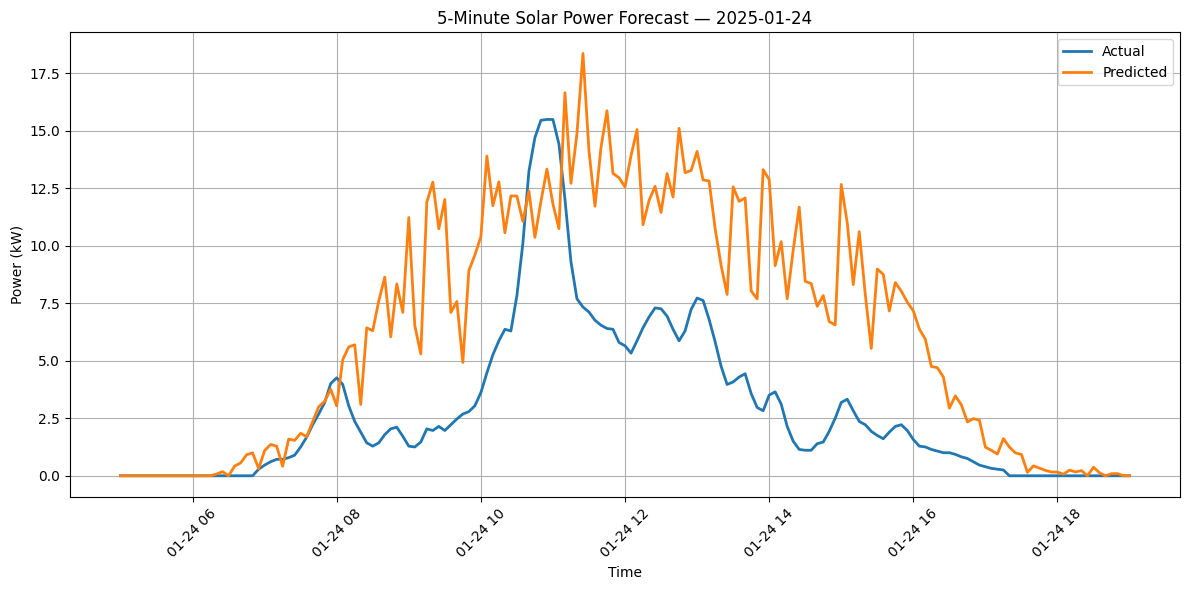

In [204]:
selected_date = "2025-01-24"

day_data = df[df["time"].dt.date == pd.to_datetime(selected_date).date()]
day_data = day_data.sort_values("time")

X_day = day_data[features]
X_day_scaled = scaler.transform(X_day)

pred_day = model.predict(X_day_scaled)
pred_day = np.clip(pred_day, 0, None)

plt.figure(figsize=(12,6))

plt.plot(day_data["time"], day_data["power"], label="Actual", linewidth=2)
plt.plot(day_data["time"], pred_day, label="Predicted", linewidth=2)

plt.title(f"5-Minute Solar Power Forecast — {selected_date}")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [205]:
import pandas as pd
import numpy as np

data = [
("2026-09-01T00:00",25.4,92,13.4,0.1),
("2026-09-01T01:00",24.6,95,12.5,0.9),
("2026-09-01T02:00",24.4,96,11.2,0.9),
("2026-09-01T03:00",24.4,96,11.2,0.3),
("2026-09-01T04:00",24.5,95,10.6,0),
("2026-09-01T05:00",24.6,95,11.1,0),
("2026-09-01T06:00",26.1,91,9.5,0),
("2026-09-01T07:00",26.9,90,9,0),
("2026-09-01T08:00",27.5,87,7.1,0),
("2026-09-01T09:00",28.8,79,10.1,0.5),
("2026-09-01T10:00",29.5,71,13.8,0),
("2026-09-01T11:00",28.9,72,18.4,0.1),
("2026-09-01T12:00",28.8,76,11.4,0.3),
("2026-09-01T13:00",29.2,74,12.5,0.2),
("2026-09-01T14:00",29.9,70,11.8,0),
("2026-09-01T15:00",30.8,66,10,0),
("2026-09-01T16:00",31.1,64,10.6,0),
("2026-09-01T17:00",30.4,68,8.9,0),
("2026-09-01T18:00",28.5,84,2.4,0),
("2026-09-01T19:00",27.8,86,2.7,0),
("2026-09-01T20:00",27.4,87,1.7,0.2),
("2026-09-01T21:00",27.2,87,3.7,0),
("2026-09-01T22:00",27.2,87,2.7,0),
("2026-09-01T23:00",26.8,85,7.4,0),
("2026-09-02T00:00",26.3,86,6.1,0),
]

future_df = pd.DataFrame(
    data,
    columns=["time","temp","humidity","wind_speed","precipitation"]
)

future_df["time"] = pd.to_datetime(future_df["time"])
future_df = future_df.set_index("time")


In [206]:
future_5min = future_df.resample("5min").interpolate(method="linear")

future_5min = future_5min.reset_index()   # THIS restores "time" column
future_5min["hour"] = future_5min["time"].dt.hour + future_5min["time"].dt.minute/60
future_5min["dayofyear"] = future_5min["time"].dt.dayofyear

In [207]:
future_5min = future_5min[
    (future_5min["time"].dt.hour > 4) &
    (future_5min["time"].dt.hour < 19)
].reset_index(drop=True)


In [208]:
future_5min["hour"] = future_5min["time"].dt.hour + future_5min["time"].dt.minute/60
future_5min["dayofyear"] = future_5min["time"].dt.dayofyear

future_5min["hour_sin"] = np.sin(2*np.pi*future_5min["hour"]/24)
future_5min["hour_cos"] = np.cos(2*np.pi*future_5min["hour"]/24)

future_5min["doy_sin"] = np.sin(2*np.pi*future_5min["dayofyear"]/365)
future_5min["doy_cos"] = np.cos(2*np.pi*future_5min["dayofyear"]/365)


In [209]:
features = [
    "temp",
    "humidity",
    "wind_speed",
    "precipitation",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

X_future = future_5min[features]


In [210]:
X_future_scaled = scaler.transform(X_future)


In [211]:
pred_power = model.predict(X_future_scaled)
pred_power = np.clip(pred_power, 0, None)

future_5min["predicted_power"] = pred_power


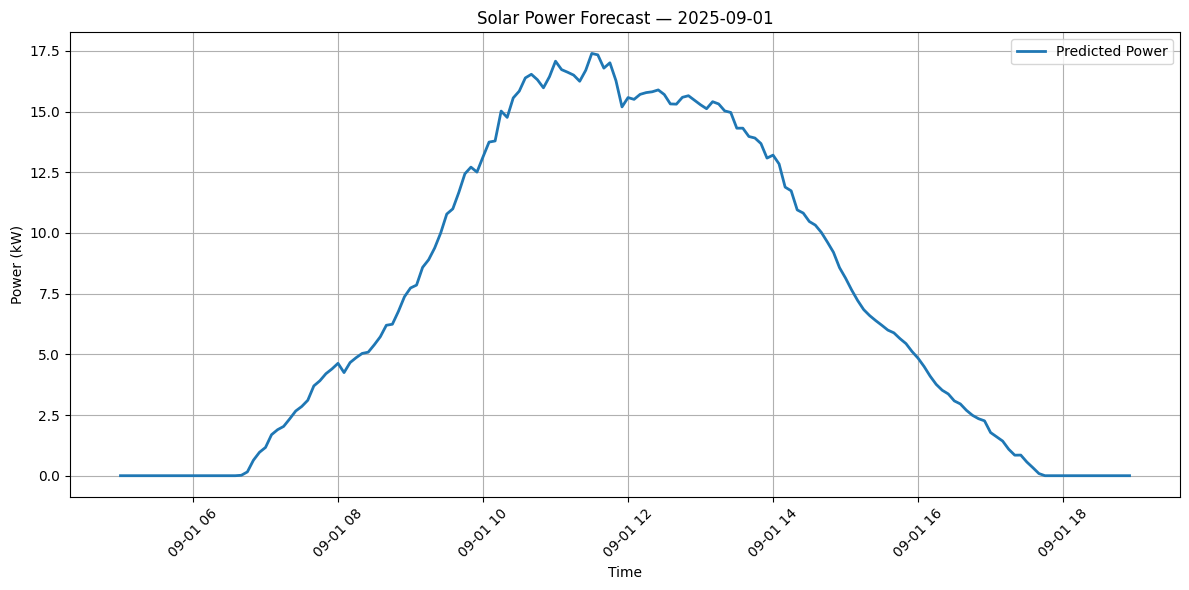

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(future_5min["time"], future_5min["predicted_power"],
         label="Predicted Power", linewidth=2)

plt.title("Solar Power Forecast — 2025-09-01")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()




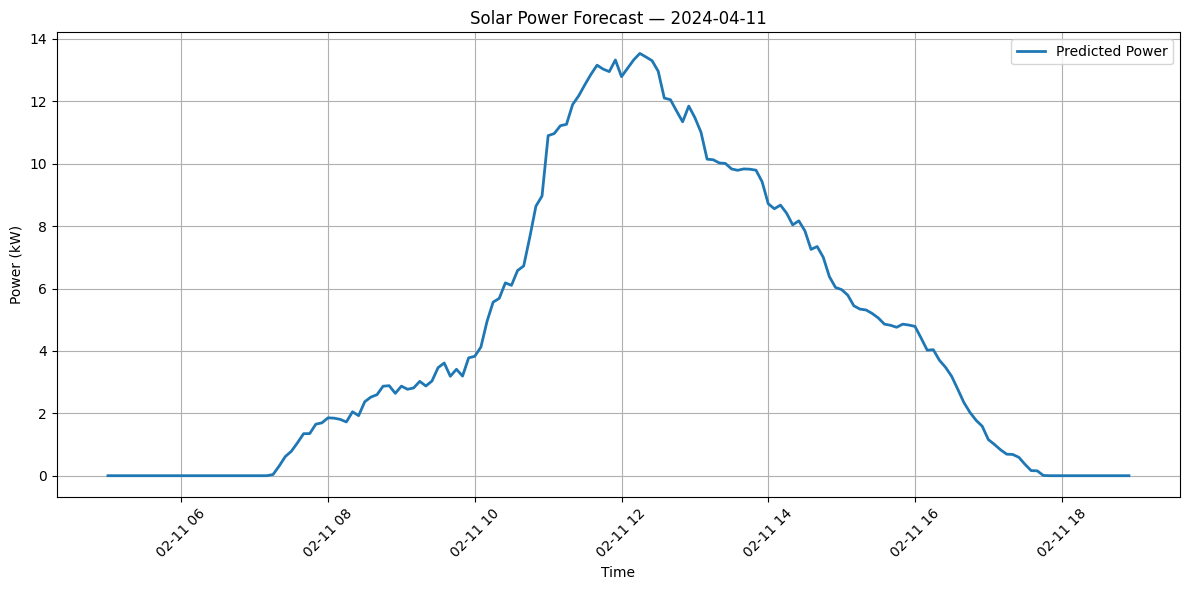

In [213]:
import pandas as pd
import numpy as np

data = [
("2027-02-10T23:00",28.1,80,6.1,0),
("2027-02-11T00:00",27.8,81,4.4,0),
("2027-02-11T01:00",27.5,82,4.8,0.1),
("2027-02-11T02:00",27.5,82,4.9,0),
("2027-02-11T03:00",26.9,85,4,0),
("2027-02-11T04:00",26.5,88,5.4,0),
("2027-02-11T05:00",26.5,89,5.6,0.1),
("2027-02-11T06:00",27.5,83,4.8,0),
("2027-02-11T07:00",28.5,77,6.2,0.1),
("2027-02-11T08:00",29.5,73,10.2,0.1),
("2027-02-11T09:00",29.5,71,11,1.6),
("2027-02-11T10:00",29.3,73,10.2,0.4),
("2027-02-11T11:00",31.2,64,13.3,0),
("2027-02-11T12:00",31.5,64,13.7,0),
("2027-02-11T13:00",31.8,63,14.4,0),
("2027-02-11T14:00",31.5,64,15.2,0),
("2027-02-11T15:00",31.1,65,14.8,0),
("2027-02-11T16:00",30.2,70,14.9,0),
("2027-02-11T17:00",29.2,71,13.4,0),
("2027-02-11T18:00",28.1,78,11.3,0),
("2027-02-11T19:00",28,81,8.9,0),
("2027-02-11T20:00",27.8,83,7.6,0),
("2027-02-11T21:00",27.6,84,5.7,0),
("2027-02-11T22:00",27.1,87,4.4,0),
("2027-02-11T23:00",27,87,5.4,0),
("2027-02-12T00:00",27,86,5.5,0),
]

future_df = pd.DataFrame(
    data,
    columns=["time","temp","humidity","wind_speed","precipitation"]
)

future_df["time"] = pd.to_datetime(future_df["time"])
future_df = future_df.set_index("time")
future_5min = future_df.resample("5min").interpolate(method="linear")

future_5min = future_5min.reset_index()   # THIS restores "time" column
future_5min["hour"] = future_5min["time"].dt.hour + future_5min["time"].dt.minute/60
future_5min["dayofyear"] = future_5min["time"].dt.dayofyear
future_5min = future_5min[
    (future_5min["time"].dt.hour > 4) &
    (future_5min["time"].dt.hour < 19)
].reset_index(drop=True)
future_5min["hour"] = future_5min["time"].dt.hour + future_5min["time"].dt.minute/60
future_5min["dayofyear"] = future_5min["time"].dt.dayofyear

future_5min["hour_sin"] = np.sin(2*np.pi*future_5min["hour"]/24)
future_5min["hour_cos"] = np.cos(2*np.pi*future_5min["hour"]/24)

future_5min["doy_sin"] = np.sin(2*np.pi*future_5min["dayofyear"]/365)
future_5min["doy_cos"] = np.cos(2*np.pi*future_5min["dayofyear"]/365)
features = [
    "temp",
    "humidity",
    "wind_speed",
    "precipitation",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]
X_future = future_5min[features]
X_future_scaled = scaler.transform(X_future)
pred_power = model.predict(X_future_scaled)
pred_power = np.clip(pred_power, 0, None)
future_5min["predicted_power"] = pred_power
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(future_5min["time"], future_5min["predicted_power"],
         label="Predicted Power", linewidth=2)

plt.title("Solar Power Forecast — 2024-04-11")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()






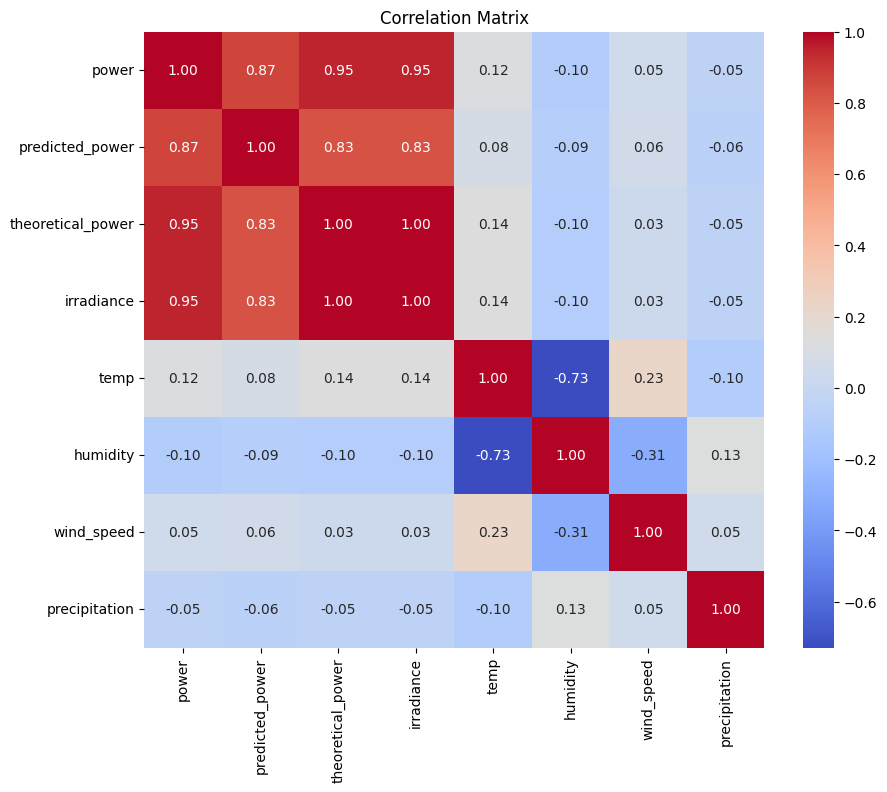

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use repaired dataframe
df_plot = df.copy()

# Add predicted power if not present
if "predicted_power" not in df_plot.columns:
    X_all = df_plot[features]
    X_scaled = scaler.transform(X_all)
    df_plot["predicted_power"] = model.predict(X_scaled)

cols = [
    "power",
    "predicted_power",
    "theoretical_power",
    "irradiance",
    "temp",
    "humidity",
    "wind_speed",
    "precipitation"
]

corr = df_plot[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

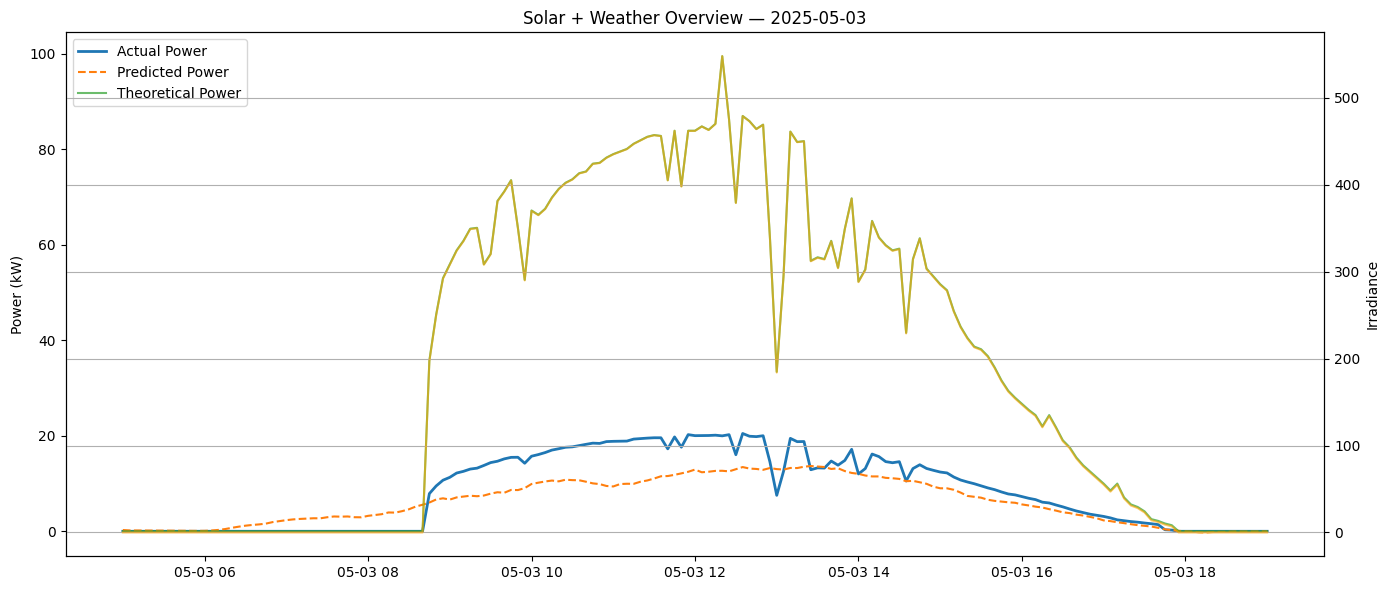

In [215]:
selected_date = "2025-05-03"
selected_date = pd.to_datetime(selected_date).date()

day = df_plot[df_plot["time"].dt.date == selected_date]

fig, ax1 = plt.subplots(figsize=(14,6))

# Power curves
ax1.plot(day["time"], day["power"], label="Actual Power", linewidth=2)
ax1.plot(day["time"], day["predicted_power"], label="Predicted Power", linestyle="--")
ax1.plot(day["time"], day["theoretical_power"], label="Theoretical Power", alpha=0.7)

ax1.set_ylabel("Power (kW)")
ax1.legend(loc="upper left")

# Secondary axis for irradiance
ax2 = ax1.twinx()
ax2.plot(day["time"], day["irradiance"], color="orange", alpha=0.6)
ax2.set_ylabel("Irradiance")

plt.title(f"Solar + Weather Overview — {selected_date}")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\mayan\AppData\Local\Temp\ipykernel_15180\1246983256.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby("weekday")


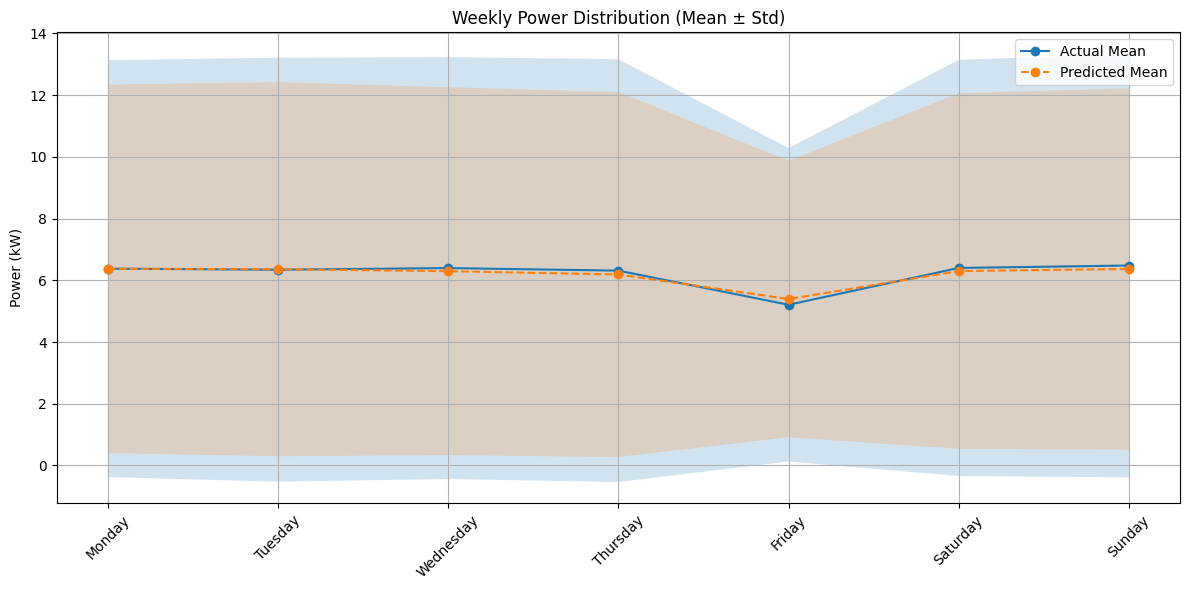

In [216]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df.copy()

# Ensure predicted exists
if "predicted_power" not in df_plot.columns:
    X_all = df_plot[features]
    X_scaled = scaler.transform(X_all)
    df_plot["predicted_power"] = model.predict(X_scaled)

df_plot["weekday"] = df_plot["time"].dt.day_name()

# Order weekdays properly
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df_plot["weekday"] = pd.Categorical(df_plot["weekday"], categories=weekday_order, ordered=True)

grouped = df_plot.groupby("weekday")

mean_actual = grouped["power"].mean()
std_actual = grouped["power"].std()

mean_pred = grouped["predicted_power"].mean()
std_pred = grouped["predicted_power"].std()

plt.figure(figsize=(12,6))

plt.plot(mean_actual.index, mean_actual, marker="o", label="Actual Mean")
plt.fill_between(mean_actual.index,
                 mean_actual - std_actual,
                 mean_actual + std_actual,
                 alpha=0.2)

plt.plot(mean_pred.index, mean_pred, marker="o", linestyle="--", label="Predicted Mean")
plt.fill_between(mean_pred.index,
                 mean_pred - std_pred,
                 mean_pred + std_pred,
                 alpha=0.2)

plt.title("Weekly Power Distribution (Mean ± Std)")
plt.ylabel("Power (kW)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()